<a href="https://colab.research.google.com/github/Jyothiswarreddy75/ITA0607-Machine-learning/blob/main/hacketan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Initial Dataset ---
    Has_Suspicious_Keywords  Unknown_Sender  Has_Attachment  Contains_Links  \
0                         1               1               1               1   
1                         0               0               0               0   
2                         1               0               1               1   
3                         0               0               1               0   
4                         1               1               0               1   
5                         0               1               0               0   
6                         1               0               0               0   
7                         0               0               0               1   
8                         1               1               1               1   
9                         1               0               1               0   
10                        0               1               0               0   
11                        0 

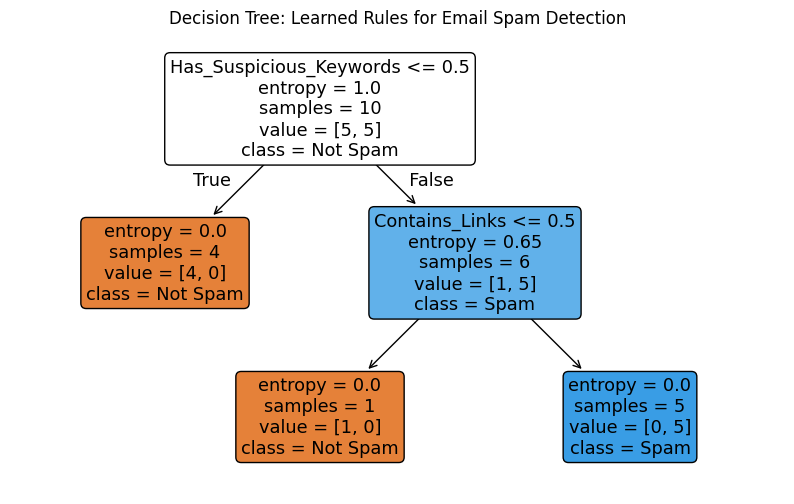

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Let's create a synthetic dataset based on your exact features
# 1 = True/Yes/Suspicious, 0 = False/No/Safe
data = {
    'Has_Suspicious_Keywords': [1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1],
    'Unknown_Sender':          [1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0],
    'Has_Attachment':          [1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1],
    'Contains_Links':          [1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1],
    # Target: 1 = Spam, 0 = Not Spam
    'Is_Spam':                 [1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1]
}

df = pd.DataFrame(data)
print("--- Initial Dataset ---")
print(df)

# ==========================================
# STEP 2: Concept Learning (Find-S Simulation)
# ==========================================
# In classic Concept Learning, we look for a specific hypothesis.
# Let's find the most specific hypothesis for "Spam" using positive examples.

print("\n--- Applying Concept Learning (Find-S Paradigm) ---")
concepts = np.array(df.iloc[:, 0:-1])
target = np.array(df.iloc[:, -1])

# Initialize the hypothesis with the first positive example
specific_h = None
for i, val in enumerate(target):
    if val == 1:
        specific_h = concepts[i].copy()
        break

# Generalize based on other positive examples
for i, val in enumerate(concepts):
    if target[i] == 1:
        for x in range(len(specific_h)):
            if val[x] != specific_h[x]:
                specific_h[x] = -1 # -1 represents '?' or 'Any' in concept learning

features = df.columns[:-1]
hypothesis_readable = [features[i] if val == 1 else ("Not " + features[i] if val == 0 else "?") for i, val in enumerate(specific_h)]
print("Most Specific Hypothesis Found:")
print(hypothesis_readable)

# ==========================================
# STEP 3: Modern ML Approach (Learning Problem)
# ==========================================
print("\n--- Training Machine Learning Classifier ---")

# Separate features (X) and target (y)
X = df.drop('Is_Spam', axis=1)
y = df['Is_Spam']

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train a Decision Tree (great for rule-based concept mapping)
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))

# ==========================================
# STEP 4: Visualize the Learned Concept Rules
# ==========================================
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X.columns, class_names=['Not Spam', 'Spam'], filled=True, rounded=True)
plt.title("Decision Tree: Learned Rules for Email Spam Detection")
plt.show()